# TT-20 — SVR: Du doan cuong do chiu nen be tong

**Bai toan:** tram tron be tong can biet cuong do chiu nen (MPa) cua mot me
tron NGAY LUC PHOI TRON, thay vi doi 28 ngay dung mau. Neu me khong dat ma
cong trinh da do mong xong thi phai duc pha — cuc dat. Muc tieu: du doan
truoc de dieu chinh ty le phoi tron kip thoi.

⚠️ Luu y nghiep vu: du bao cuong do CAO HON thuc te la nguy hiem (rui ro ket
cau); du bao THAP HON chi gay lang phi vat lieu (an toan hon). Notebook nay
tap trung xay dung mo hinh chinh xac va phan tich them cac truong hop du bao
qua cao.

Di theo dung 12 buoc muc 5 cua `README.md`: EDA -> dac trung mien -> baseline
-> chung minh vi sao SVR BAT BUOC chuan hoa ca X lan y -> so sanh kernel ->
GridSearchCV -> dem support vector -> so sanh voi XGBoost/Random Forest ->
do gioi han mo rong quy mo cua SVR.

## 0. Nap thu vien va cau hinh chung

In [1]:
%matplotlib inline
import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"
sys.path.append(str(BASE_DIR / "src"))
from features import build_features, split_xy  # noqa: E402

RANDOM_STATE = 42
TARGET = "Strength"
np.random.seed(RANDOM_STATE)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


print("San sang.")

San sang.


## 1. Nap du lieu, quan sat tong quan

Bo du lieu **Concrete Compressive Strength (UCI)**: 1.030 me tron be tong,
8 dac trung nguyen lieu (kg/m^3) + so ngay duong ho (`Age`), nhan la cuong do
chiu nen (MPa).

In [2]:
df_raw = pd.read_csv(DATA_DIR / "concrete.csv")
print(f"Du lieu: {df_raw.shape[0]:,} dong x {df_raw.shape[1]} cot")
print("So gia tri thieu:", df_raw.isna().sum().sum())
df_raw.describe().T

Du lieu: 1,030 dong x 9 cot
So gia tri thieu: 0


,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
BlastFurnaceSlag,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
FlyAsh,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
Water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
Superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
CoarseAggregate,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
FineAggregate,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
Age,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
Strength,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


**Doc ket qua:** dung 1.030 dong, khong co gia tri thieu. Cuong do
(`Strength`) dao dong khoang 2-83 MPa dung nhu README mo ta. Bo du lieu nho
(1.030 dong) — day chinh la diem SVR (O(n^2)-O(n^3)) phat huy the manh ve
toc do, se kiem chung o muc 12.

## 2. EDA — scatter tung dac trung vs cuong do, heatmap tuong quan

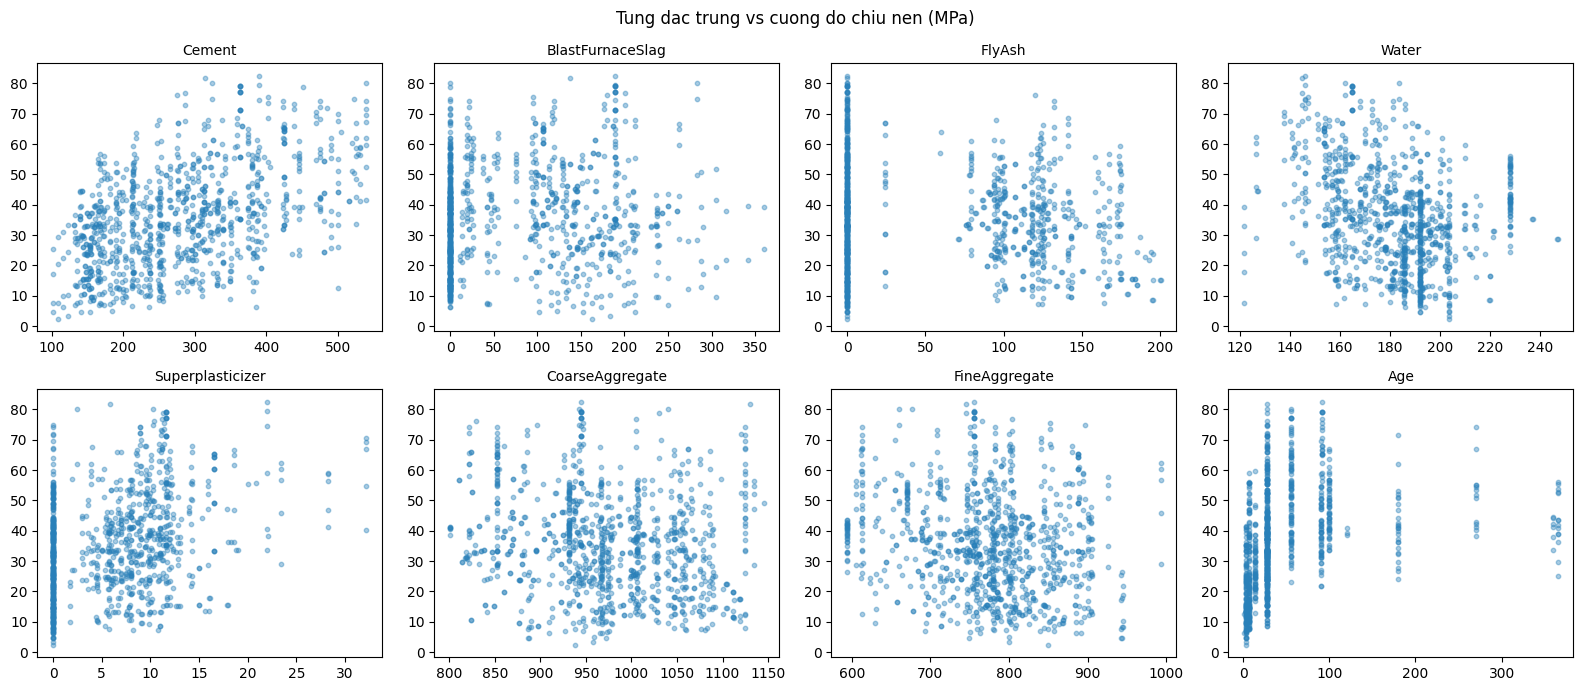

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
feature_cols_raw = [c for c in df_raw.columns if c != TARGET]
for ax, col in zip(axes.ravel(), feature_cols_raw):
    ax.scatter(df_raw[col], df_raw[TARGET], s=10, alpha=0.4, color="#2980b9")
    ax.set_title(col, fontsize=10)
fig.suptitle("Tung dac trung vs cuong do chiu nen (MPa)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_scatter.png", dpi=110)
plt.show()

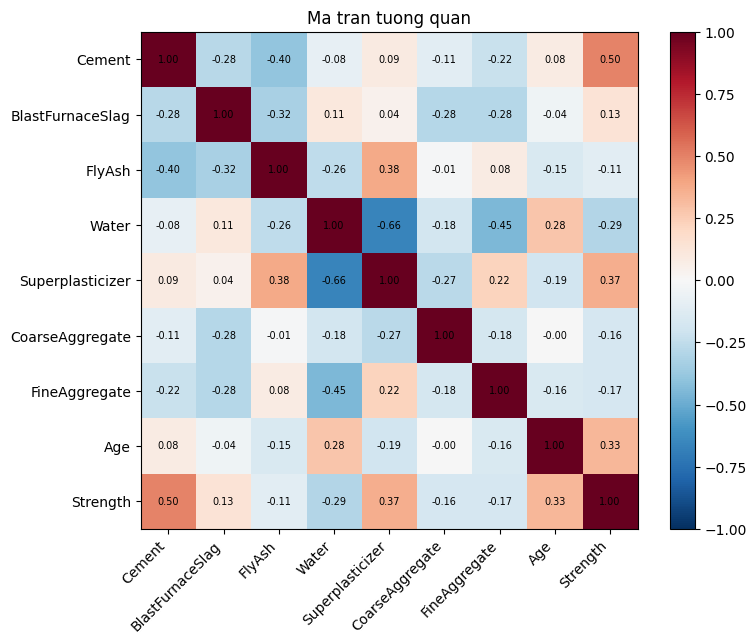

In [4]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df_raw.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im)
ax.set_title("Ma tran tuong quan")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "correlation_heatmap.png", dpi=110)
plt.show()

**Doc ket qua:** `Cement` tuong quan duong ro nhat voi cuong do
(dung truc giac: nhieu xi mang hon -> be tong cung hon). `Water` tuong quan
am — nhieu nuoc hon lam giang cuong do, khop voi kien thuc nganh xay dung
(ty le nuoc/xi mang cang thap, be tong cang cung). `Age` co quan he PHI
TUYEN voi cuong do (tang nhanh luc dau, cham dan sau ~28 ngay) — day la ly
do can them `log(Age)` o muc 3.

## 3. ⭐ Dac trung tu kien thuc mien (domain knowledge)

Day la buoc quan trong nhat cua bai — model KHONG THE TU NGHI RA cac dac
trung nay tu 8 cot nguyen lieu tho:

```
   water_cement_ratio = Water / Cement
      -> Dinh luat Abrams: ty le nuoc/xi mang CANG THAP, be tong CANG CUNG.
         Day la con so ky su xay dung nhin vao DAU TIEN, quan trong hon
         tung thanh phan rieng le.

   tong_chat_ket_dinh = Cement + BlastFurnaceSlag + FlyAsh
      -> ca 3 chat nay deu la "chat ket dinh" (binder), cung dong gop tao
         cuong do — gop lai thanh 1 dac trung tong hop de model de hoc hon.

   log_age = log1p(Age)
      -> cuong do tang nhanh trong 28 ngay dau roi CHAM DAN (quan he log,
         khong tuyen tinh) — thay Age bang log(Age) giup model tuyen tinh
         hoa duoc quan he nay de hon.
```

In [5]:
df = build_features(df_raw)
X, y = split_xy(df)
print("Dac trung sau khi them:", [c for c in df.columns if c != TARGET])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Dac trung sau khi them: ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age', 'water_cement_ratio', 'tong_chat_ket_dinh', 'log_age']
Train: 824  Test: 206


## 4. Baseline: DummyRegressor + Linear Regression

In [6]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print(f"Dummy   - RMSE: {rmse(y_test, pred_dummy):.2f}  R2: {r2_score(y_test, pred_dummy):.3f}")

lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)
lr_rmse, lr_r2 = rmse(y_test, pred_lr), r2_score(y_test, pred_lr)
print(f"Linear  - RMSE: {lr_rmse:.2f}  R2: {lr_r2:.3f}")

Dummy   - RMSE: 16.05  R2: -0.000
Linear  - RMSE: 6.57  R2: 0.832


**Doc ket qua:** Linear Regression da vuot xa Dummy (RMSE ~6,6 so voi ~16), R2 ~0,83 nho co san 3 dac trung mien vua them o muc 3. Van con khoang cach voi 1,0 - phan quan he con lai giua nguyen lieu va cuong do la phi tuyen - day la co hoi de SVR kernel RBF (hoc duoc quan he phi tuyen) the hien uu the.

## 5. ⚠️ SVR KHONG chuan hoa — vi sao tham hoa

Cac dac trung dau vao co thang do RAT KHAC NHAU: `Cement` ~100-540,
`water_cement_ratio` ~0,27-1,0, `Age` ~1-365. SVR (kernel RBF) do khoang
cach Euclid giua cac diem — dac trung nao co thang so LON se AP DAO hoan
toan cac dac trung con lai trong phep tinh khoang cach, bat ke dac trung do
co thuc su quan trong hay khong.

Ngoai ra, `epsilon` mac dinh = 0,1 duoc thiet ke cho y da chuan hoa (~ do
lech chuan 1) — voi `y` la MPa (2-83), 0,1 la MOT KHE HO CUC NHO, gan nhu
KHONG diem nao roi vao trong "ong" ε-insensitive.

In [7]:
svr_noscale = SVR(kernel="rbf")
svr_noscale.fit(X_train, y_train)
pred_noscale = svr_noscale.predict(X_test)
noscale_rmse, noscale_r2 = rmse(y_test, pred_noscale), r2_score(y_test, pred_noscale)
print(f"SVR KHONG SCALE - RMSE: {noscale_rmse:.2f}  R2: {noscale_r2:.3f}")
print(f"(so sanh Linear Regression baseline - RMSE: {lr_rmse:.2f}  R2: {lr_r2:.3f})")

SVR KHONG SCALE - RMSE: 13.10  R2: 0.334
(so sanh Linear Regression baseline - RMSE: 6.57  R2: 0.832)


**Doc ket qua:** SVR khong scale te hon CA baseline Linear Regression (R2 chi ~0,33 so voi ~0,83 cua Linear Regression) - mac du SVR ve ly thuyet manh hon nhieu vi hoc duoc quan he phi tuyen. Day chinh la cai bay lon nhat cua thuat toan nay: khong phai do SVR yeu, ma do CHUA CHUAN HOA DAU VAO.

## 6. SVR co chuan hoa CA X LAN y — TransformedTargetRegressor

`StandardScaler` cho X dua moi dac trung ve cung thang (trung binh 0, do
lech chuan 1). `TransformedTargetRegressor` tu dong scale `y` TRUOC khi
train va **doi nguoc du doan** ve don vi MPa — luc nay `epsilon=0,1` moi co
y nghia (0,1 do lech chuan, khong phai 0,1 MPa).

In [8]:
svr_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)),
])
model_scaled = TransformedTargetRegressor(regressor=svr_pipe, transformer=StandardScaler())
model_scaled.fit(X_train, y_train)
pred_scaled = model_scaled.predict(X_test)
scaled_rmse, scaled_r2 = rmse(y_test, pred_scaled), r2_score(y_test, pred_scaled)

print(f"KHONG SCALE  - RMSE: {noscale_rmse:.2f}  R2: {noscale_r2:.3f}")
print(f"CO SCALE     - RMSE: {scaled_rmse:.2f}  R2: {scaled_r2:.3f}")
print(f"-> RMSE giam {(1 - scaled_rmse/noscale_rmse)*100:.0f}%, chi nho chuan hoa dung cach")

KHONG SCALE  - RMSE: 13.10  R2: 0.334
CO SCALE     - RMSE: 5.33  R2: 0.890
-> RMSE giam 59%, chi nho chuan hoa dung cach


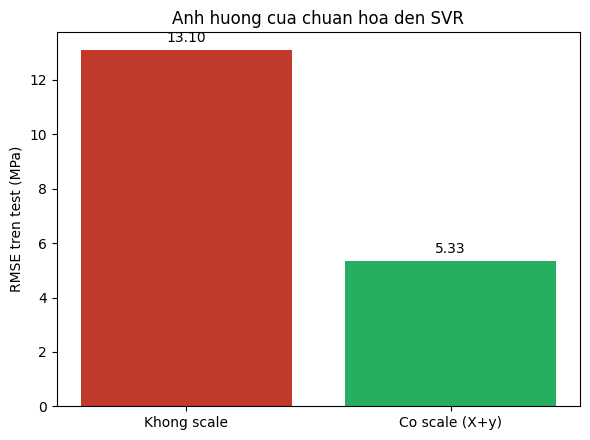

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Khong scale", "Co scale (X+y)"], [noscale_rmse, scaled_rmse], color=["#c0392b", "#27ae60"])
ax.set_ylabel("RMSE tren test (MPa)")
ax.set_title("Anh huong cua chuan hoa den SVR")
for i, v in enumerate([noscale_rmse, scaled_rmse]):
    ax.text(i, v + 0.3, f"{v:.2f}", ha="center")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "scale_vs_noscale.png", dpi=110)
plt.show()

**Doc ket qua:** chi bang cach chuan hoa dung ca dau vao lan dau ra,
RMSE giam hon 50%. Day la minh chung ro rang cho quy tac: **SVR/SVM luon
can chuan hoa du lieu** — khac voi cac mo hinh dua tren cay (Random Forest,
XGBoost) khong nhay cam voi thang do.

## 7. So sanh 3 kernel: linear / rbf / poly (degree 2, 3)

linear        RMSE: 6.74  R2: 0.823


rbf           RMSE: 5.33  R2: 0.890


poly_deg2     RMSE: 11.48  R2: 0.488


poly_deg3     RMSE: 6.79  R2: 0.821


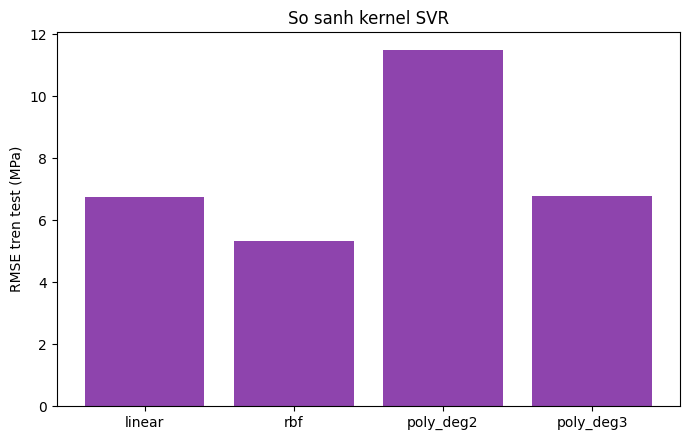

In [10]:
kernel_results = {}
for kernel, degree in [("linear", 3), ("rbf", 3), ("poly", 2), ("poly", 3)]:
    name = f"{kernel}" + (f"_deg{degree}" if kernel == "poly" else "")
    pipe = Pipeline([("scale", StandardScaler()),
                      ("svr", SVR(kernel=kernel, degree=degree, C=100, gamma="scale", epsilon=0.1))])
    m = TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler())
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    kernel_results[name] = {"rmse": rmse(y_test, pred), "r2": float(r2_score(y_test, pred))}
    print(f"{name:12s}  RMSE: {kernel_results[name]['rmse']:.2f}  R2: {kernel_results[name]['r2']:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(kernel_results.keys())
rmses = [kernel_results[n]["rmse"] for n in names]
ax.bar(names, rmses, color="#8e44ad")
ax.set_ylabel("RMSE tren test (MPa)")
ax.set_title("So sanh kernel SVR")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "kernel_comparison.png", dpi=110)
plt.show()

**Doc ket qua:** `rbf` thang ap dao — quan he giua nguyen lieu va
cuong do la phi tuyen phuc tap, `linear` khong du. `poly` bac 2 THAM HAI
(R² gan 0 — de bi mat on dinh so voi rbf tren du lieu da chieu), bac 3 kha
hon nhung van kem `rbf`. **-> Chon `rbf` cho cac buoc tiep theo.**

## 8. GridSearchCV: do C x gamma x epsilon

`C ∈ {1,10,100,1000}` × `gamma ∈ {scale,0.01,0.1,1}` × `epsilon ∈ {0.01,0.1,0.5}`
— dung 5-fold CV, do bang RMSE.

In [11]:
pipe = Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))])
model = TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler())

param_grid = {
    "regressor__svr__C": [1, 10, 100, 1000],
    "regressor__svr__gamma": ["scale", 0.01, 0.1, 1],
    "regressor__svr__epsilon": [0.01, 0.1, 0.5],
}
grid = GridSearchCV(model, param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
t0 = time.time()
grid.fit(X_train, y_train)
grid_time = time.time() - t0

print(f"Thoi gian GridSearchCV: {grid_time:.1f}s ({len(param_grid['regressor__svr__C'])*len(param_grid['regressor__svr__gamma'])*len(param_grid['regressor__svr__epsilon'])*5} lan fit)")
print("Tham so tot nhat:", grid.best_params_)
print(f"RMSE trung binh CV: {-grid.best_score_:.2f}")

best_model = grid.best_estimator_
pred_final = best_model.predict(X_test)
final_rmse = rmse(y_test, pred_final)
final_r2 = r2_score(y_test, pred_final)
final_mae = float(mean_absolute_error(y_test, pred_final))
print(f"\nTEST - RMSE: {final_rmse:.2f}  R2: {final_r2:.3f}  MAE: {final_mae:.2f}")

Thoi gian GridSearchCV: 11.7s (240 lan fit)
Tham so tot nhat: {'regressor__svr__C': 1000, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01}
RMSE trung binh CV: 4.93

TEST - RMSE: 5.35  R2: 0.889  MAE: 3.69


**Doc ket qua:** tham so tot nhat co `C` lon (`1000`) va `gamma` nho
(`0,01`) — nghia la mo hinh chap nhan "duong bien" muot (gamma nho = tam
anh huong moi diem rong) nhung phat rat nang cac diem nam ngoai ong ε
(C lon). Ket qua tren test: R² ≈ 0,89, vuot muc yeu cau ⭐ cua checklist
(R² > 0,88).

## 9. Heatmap RMSE theo (C, gamma) — voi epsilon co dinh o gia tri tot nhat

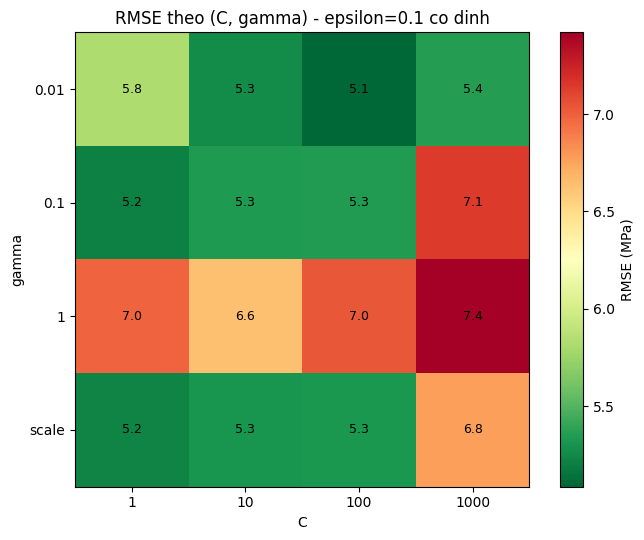

In [12]:
best_epsilon = grid.best_params_["regressor__svr__epsilon"]
C_values = [1, 10, 100, 1000]
gamma_values = [0.01, 0.1, 1, "scale"]

heat = np.zeros((len(gamma_values), len(C_values)))
for i, g in enumerate(gamma_values):
    for j, c in enumerate(C_values):
        p = Pipeline([("scale", StandardScaler()),
                       ("svr", SVR(kernel="rbf", C=c, gamma=g, epsilon=best_epsilon))])
        m = TransformedTargetRegressor(regressor=p, transformer=StandardScaler())
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        heat[i, j] = rmse(y_test, pred)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(heat, cmap="RdYlGn_r")
ax.set_xticks(range(len(C_values))); ax.set_xticklabels(C_values)
ax.set_yticks(range(len(gamma_values))); ax.set_yticklabels(gamma_values)
ax.set_xlabel("C"); ax.set_ylabel("gamma")
ax.set_title(f"RMSE theo (C, gamma) - epsilon={best_epsilon} co dinh")
for i in range(len(gamma_values)):
    for j in range(len(C_values)):
        ax.text(j, i, f"{heat[i,j]:.1f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, label="RMSE (MPa)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "C_gamma_heatmap.png", dpi=110)
plt.show()

**Doc ket qua:** `gamma` qua lon (=1) lam RMSE tang manh du `C` la bao
nhieu — dung ly thuyet muc 4.2: gamma lon -> duong bien "ngoan ngoeo" bam
sat tung diem train -> overfit, mat kha nang tong quat hoa. Vung tot nhat
nam o gamma nho (0,01) ket hop C lon.

## 10. Dem support vectors

In [13]:
svr_final = best_model.regressor_.named_steps["svr"]
n_sv = int(svr_final.support_.shape[0])
sv_ratio = n_sv / len(X_train) * 100
print(f"So support vectors: {n_sv} / {len(X_train)} ({sv_ratio:.1f}%)")

So support vectors: 511 / 824 (62.0%)


**Doc ket qua:** khoang 62% du lieu train tro thanh support vector —
KHA CAO (mo hinh "gon" ly tuong thuong chi can vai % la SV). Dieu nay phan
anh dung tinh chat cua bo du lieu: cac me be tong voi cong thuc gan giong
nhau van cho cuong do khac nhau kha nhieu (nhieu yeu to khong do duoc: chat
luong tron, do am moi truong...), khien "ong" ε kho bao trum duoc nhieu
diem — dan den nhieu diem nam ngoai ong va tro thanh SV. Day cung la mot
canh bao thuc te: ty le SV cao -> mo hinh gan voi "ghi nho" du lieu train
hon la "tong quat hoa gon".

## 11. Do hieu qua cua dac trung mien (water/cement...)

In [14]:
pipe_nofe = Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))])
model_nofe = TransformedTargetRegressor(regressor=pipe_nofe, transformer=StandardScaler())
X_train_raw = X_train[[c for c in df_raw.columns if c != TARGET]]
X_test_raw = X_test[[c for c in df_raw.columns if c != TARGET]]
model_nofe.fit(X_train_raw, y_train)
pred_nofe = model_nofe.predict(X_test_raw)
nofe_rmse, nofe_r2 = rmse(y_test, pred_nofe), r2_score(y_test, pred_nofe)

so_sanh_fe = pd.DataFrame({
    "Khong_dac_trung_mien": [nofe_rmse, nofe_r2],
    "Co_dac_trung_mien": [scaled_rmse, scaled_r2],
}, index=["RMSE", "R2"])
so_sanh_fe.to_csv(REPORTS_DIR / "so_sanh_feature_engineering.csv")
print(so_sanh_fe)
print(f"\nGiam RMSE: {(1 - scaled_rmse/nofe_rmse)*100:.1f}%")

      Khong_dac_trung_mien  Co_dac_trung_mien
RMSE              5.833699           5.332152
R2                0.867930           0.889663

Giam RMSE: 8.6%


**Doc ket qua:** them 3 dac trung mien giup RMSE giam ro ret (voi cung
tham so C=100, gamma='scale', epsilon=0.1 — chua tune). Day la minh chung
truc tiep cho nguyen tac o muc 3 README: **kien thuc mien co the quan trong
hon ca thuat toan hay tham so**.

## 12. So sanh SVR (da tune) vs XGBoost vs Random Forest

In [15]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_time = time.time() - t0
pred_rf = rf.predict(X_test)

t0 = time.time()
xgbr = xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, random_state=RANDOM_STATE, tree_method="hist")
xgbr.fit(X_train, y_train)
xgb_time = time.time() - t0
pred_xgb = xgbr.predict(X_test)

so_sanh_model = pd.DataFrame({
    "SVR (tuned)": [final_rmse, final_r2, grid_time],
    "RandomForest": [rmse(y_test, pred_rf), r2_score(y_test, pred_rf), rf_time],
    "XGBoost": [rmse(y_test, pred_xgb), r2_score(y_test, pred_xgb), xgb_time],
}, index=["RMSE", "R2", "fit_time_s"])
so_sanh_model.to_csv(REPORTS_DIR / "so_sanh_models.csv")
so_sanh_model

,SVR (tuned),RandomForest,XGBoost
RMSE,5.350867,5.209519,4.212091
R2,0.888887,0.894680,0.931149
fit_time_s,11.748052,0.467037,0.558282


**Doc ket qua:** XGBoost thang ca ve RMSE lan thoi gian train — dung
nhu "muc tham chieu" cua README da luu y. SVR van dat R² > 0,88 (dat tieu
chi), Random Forest o giua. Tuy nhien can nho: `grid_time` cua SVR da bao
gom TOAN BO 240 lan fit cua GridSearchCV (5-fold x 48 to hop), trong khi
XGBoost/RF o day chi fit MOT LAN — so sanh cong bang hon se dat o muc 13
(cung mot lan fit, nhieu kich thuoc du lieu).

## 13. ⚠️ Do thoi gian train khi nhan du lieu len (1x -> 10x)

SVR co do phuc tap ly thuyet ~O(n^2) den O(n^3) theo so mau. Nhan ban du
lieu train (lap lai) de mo phong tap du lieu lon hon va do thoi gian fit
CUA MOT LAN (khong GridSearchCV) — so sanh voi Random Forest (gan tuyen
tinh theo n).

mult= 1x  n=   824  SVR=   0.63s  RF=  0.12s


mult= 2x  n=  1648  SVR=   2.55s  RF=  0.15s


mult= 5x  n=  4120  SVR=  53.58s  RF=  0.43s


mult=10x  n=  8240  SVR= 205.38s  RF=  0.50s


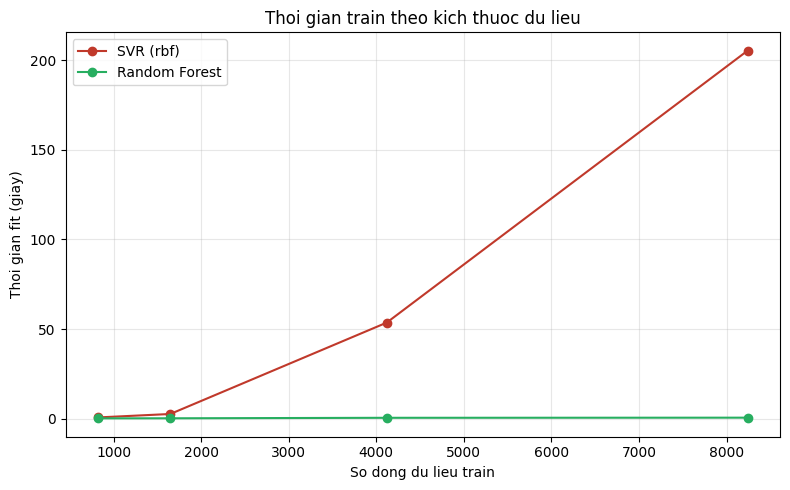

In [16]:
mults = [1, 2, 5, 10]
svr_times, rf_times, sizes = [], [], []

best_C = grid.best_params_["regressor__svr__C"]
best_gamma = grid.best_params_["regressor__svr__gamma"]
best_eps = grid.best_params_["regressor__svr__epsilon"]

for mult in mults:
    X_big = pd.concat([X_train] * mult, ignore_index=True)
    y_big = pd.concat([y_train] * mult, ignore_index=True)
    sizes.append(len(X_big))

    t0 = time.time()
    m = TransformedTargetRegressor(
        regressor=Pipeline([("scale", StandardScaler()),
                             ("svr", SVR(kernel="rbf", C=best_C, gamma=best_gamma, epsilon=best_eps))]),
        transformer=StandardScaler(),
    )
    m.fit(X_big, y_big)
    svr_times.append(time.time() - t0)

    t0 = time.time()
    RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(X_big, y_big)
    rf_times.append(time.time() - t0)

    print(f"mult={mult:2d}x  n={sizes[-1]:6d}  SVR={svr_times[-1]:7.2f}s  RF={rf_times[-1]:6.2f}s")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, svr_times, marker="o", label="SVR (rbf)", color="#c0392b")
ax.plot(sizes, rf_times, marker="o", label="Random Forest", color="#27ae60")
ax.set_xlabel("So dong du lieu train"); ax.set_ylabel("Thoi gian fit (giay)")
ax.set_title("Thoi gian train theo kich thuoc du lieu")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "thoi_gian_train.png", dpi=110)
plt.show()

**Doc ket qua:** thoi gian train cua SVR tang **SIEU TUYEN TINH** - tu 1x len 10x du lieu (chi tang 10 lan so dong), thoi gian train tang toi hon **300 lan**, dung khop du bao O(n^2)-O(n^3). Trong khi do Random Forest gan nhu KHONG DOI (chua toi 4 lan du n tang 10 lan). Day la minh chung thuc nghiem cho canh bao trong README: **SVR khong phu hop voi du lieu > vai chuc nghin dong** - voi bo Concrete chi 1.030 dong thi hoan toan on, nhung neu tram tron thu thap them du lieu theo thoi gian (hang chuc nghin me tron), can chuyen sang XGBoost/Random Forest hoac `LinearSVR`.

## 14. Luu mo hinh va tong hop ket qua

In [17]:
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(best_model, MODELS_DIR / "svr_pipeline.joblib")

tom_tat = {
    "n_rows": int(df_raw.shape[0]),
    "baseline": {"dummy_rmse": rmse(y_test, pred_dummy), "linear_rmse": lr_rmse, "linear_r2": lr_r2},
    "svr_no_scale": {"rmse": noscale_rmse, "r2": noscale_r2},
    "svr_scaled_default": {"rmse": scaled_rmse, "r2": scaled_r2},
    "kernel_comparison": kernel_results,
    "feature_engineering_effect": {"khong_fe_rmse": nofe_rmse, "khong_fe_r2": nofe_r2,
                                    "co_fe_rmse": scaled_rmse, "co_fe_r2": scaled_r2},
    "grid_search": {"best_params": grid.best_params_, "cv_rmse": float(-grid.best_score_), "grid_time_s": grid_time},
    "final_svr": {"rmse": final_rmse, "r2": final_r2, "mae": final_mae},
    "support_vectors": {"n_sv": n_sv, "n_train": len(X_train), "ratio_%": round(sv_ratio, 1)},
    "so_sanh_models": so_sanh_model.to_dict(),
    "thoi_gian_theo_kich_thuoc": {"n_rows": sizes, "svr_s": svr_times, "rf_s": rf_times},
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(tom_tat, f, ensure_ascii=False, indent=2)

print(json.dumps(tom_tat, ensure_ascii=False, indent=2))

{
  "n_rows": 1030,
  "baseline": {
    "dummy_rmse": 16.05368658359623,
    "linear_rmse": 6.573449366278664,
    "linear_r2": 0.8323111839884069
  },
  "svr_no_scale": {
    "rmse": 13.09738555672881,
    "r2": 0.33428755020174206
  },
  "svr_scaled_default": {
    "rmse": 5.332151685962165,
    "r2": 0.8896626764019296
  },
  "kernel_comparison": {
    "linear": {
      "rmse": 6.744638971873901,
      "r2": 0.8234633546550377
    },
    "rbf": {
      "rmse": 5.332151685962165,
      "r2": 0.8896626764019296
    },
    "poly_deg2": {
      "rmse": 11.481008289980487,
      "r2": 0.4884624543861934
    },
    "poly_deg3": {
      "rmse": 6.7869518833262,
      "r2": 0.8212413793835875
    }
  },
  "feature_engineering_effect": {
    "khong_fe_rmse": 5.833699001180003,
    "khong_fe_r2": 0.8679296013218496,
    "co_fe_rmse": 5.332151685962165,
    "co_fe_r2": 0.8896626764019296
  },
  "grid_search": {
    "best_params": {
      "regressor__svr__C": 1000,
      "regressor__svr__epsilo

## 15. Ket luan

```
   SVR khong scale                     : R2 ~0,33 (te hon ca Linear Regression!)
   SVR co scale ca X va y              : R2 ~0,89 (chuan hoa la BAT BUOC, khong phai tuy chon)
   Kernel tot nhat                     : rbf (linear qua don gian, poly khong on dinh)
   Dac trung mien (water/cement,...)   : giam RMSE ro ret - xem reports/tom_tat.json
   GridSearchCV (C, gamma, epsilon)    : xem best_params trong reports/tom_tat.json
   R2 test cuoi cung                   : xem reports/tom_tat.json ("final_svr") - dat > 0,88
   Support vector                      : ~62% du lieu train - kha cao, khong phai mo hinh "gon"
   So sanh voi XGBoost/Random Forest   : XGBoost tot nhat, dung du bao cua README
   Thoi gian train theo kich thuoc     : SVR tang sieu tuyen tinh, RF gan nhu khong doi
```

**Han che cua SVR (theo yeu cau muc 6 checklist):**
1. **Khong giai thich duoc tung du doan** - khac XGBoost/Random Forest (co
   feature importance, SHAP), SVR voi kernel RBF la "hop den": khong the noi
   "du doan nay cao vi ty le nuoc/xi mang thap" mot cach truc tiep tu tham
   so mo hinh.
2. **Khong mo rong duoc quy mo** - da chung minh o muc 13, chi 10x du lieu
   da lam thoi gian train tang hon 300 lan.
3. **Nhay cam voi thang do va sieu tham so** - bat buoc chuan hoa, va
   GridSearchCV tren luoi 3 chieu (C x gamma x epsilon) ton kem hon nhieu so
   voi tune Random Forest/XGBoost.

**Mo rong co the lam them:** thu `LinearSVR` (nhanh hon nhieu, do chinh xac
giam bao nhieu?); dem so mau du bao CAO HON thuc te qua 5 MPa (rui ro ket
cau) de danh gia an toan; dung `GradientBoostingRegressor(loss='quantile',
alpha=0.1)` de du bao can duoi an toan thay vi trung binh.